# Ejercicios Prácticos - Actividad 5

1. Seleccionar un conjunto de datos para una tarea de regresión que de tu interés, disponible en alguno de los repositorios mencionados en clase.
2. Tratar los valores perdidos de la serie si tiene.
3. Aplicar al menos una transformación (en los modelos ARIMA/SARIMA es aplicar una transformación diferente a la diferenciación).
4. Aplicar a la serie modelos ARIMA/SARIMA y ARnet a la serie de tiempo.
5. Realizar análisis residuales
6. Comparar resultados

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

El dataset fue obtenido de <b>Kaggle</b>

Fuente: https://www.kaggle.com/datasets/mikhail1681/walmart-sales

In [ ]:
dataset = pd.read_csv("Walmart_Sales.csv")  # Según la documentación no cuenta con datos null

# Dado que el dataset tienen múltiples características, yo me enfocaré en transformar mi dataset
# para obtener el número de ventas por semana.

dataset["Date"] = pd.to_datetime(dataset["Date"], dayfirst=True)

serie = dataset.groupby("Date")["Weekly_Sales"].sum()

serie = serie.sort_index()

# Después de transformar el dataset lo que se espera es tener el número de ventas por semana
print(f"{serie}")

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
                 ...     
2012-09-28    43734899.40
2012-10-05    47566639.31
2012-10-12    46128514.25
2012-10-19    45122410.57
2012-10-26    45544116.29
Name: Weekly_Sales, Length: 143, dtype: float64


## Visualización de la serie

Número total de registros: 143


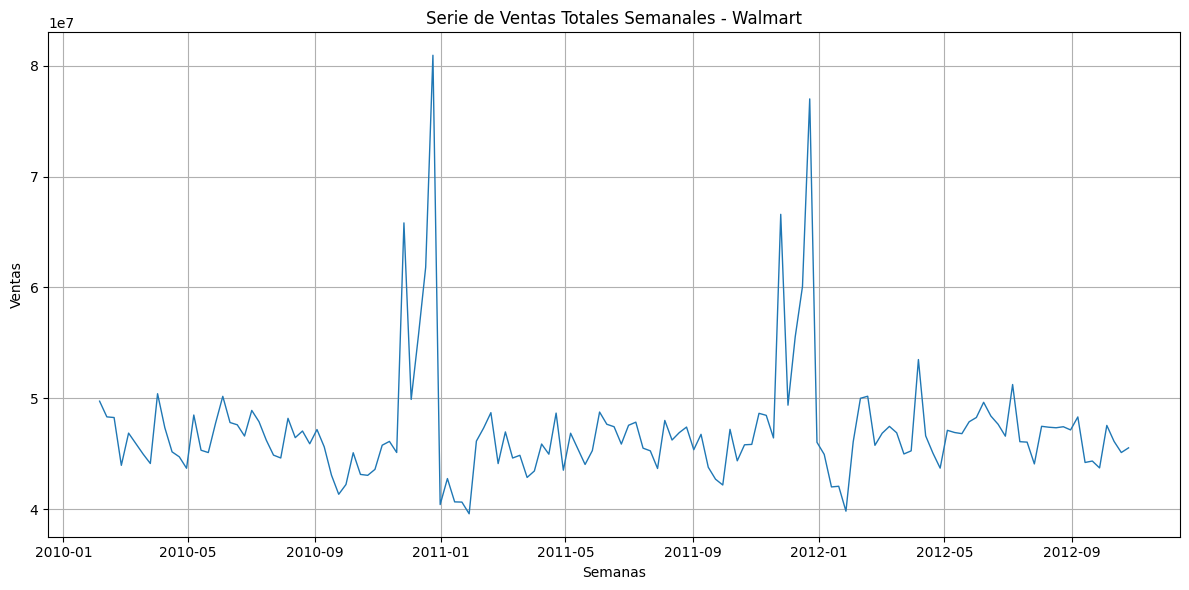

Serie visualizada correctamente


In [18]:
print(f"Número total de registros: {len(serie)}")

# Dado que en nuestra Serie ya contamos con un indice que es la semana, no es necesario crear un indice artificial.

# Visualizamos nuestra serie

plt.figure(figsize=(12,6))
plt.plot(serie, linewidth=1)
plt.title("Serie de Ventas Totales Semanales - Walmart")
plt.xlabel("Semanas")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Serie visualizada correctamente")

## Valores perdidos

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

El dataset descargado según la documentación no contiene valores perdidos, por lo que realizaré una copia de mi serie y simularemos una serie de prueba con valores perdidos para aplicar los métodos.

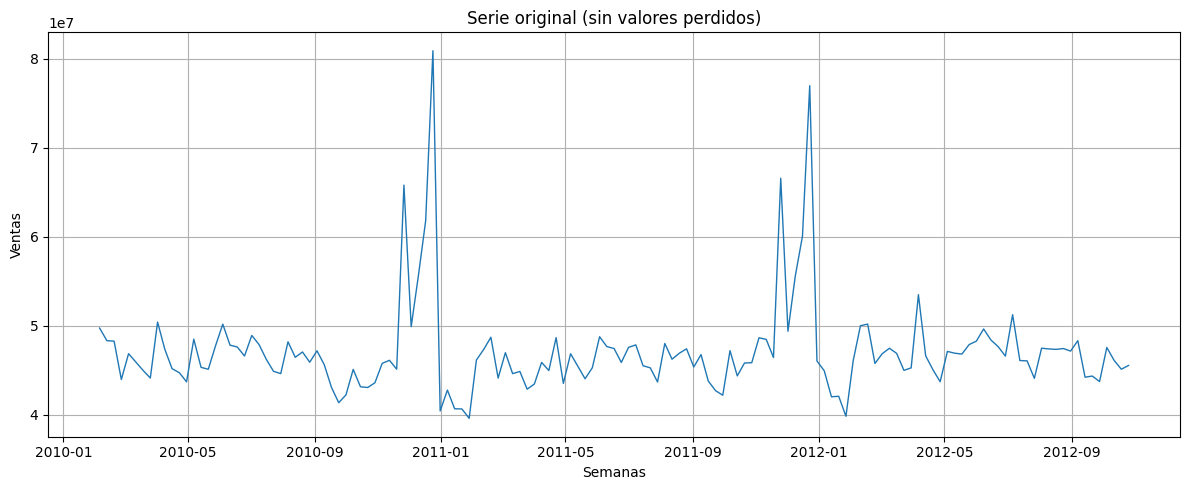

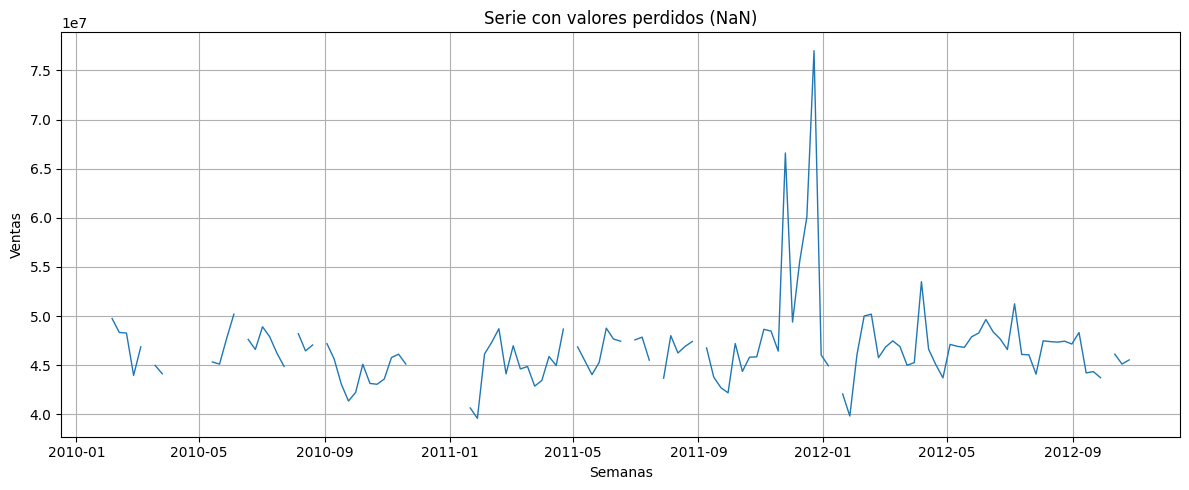

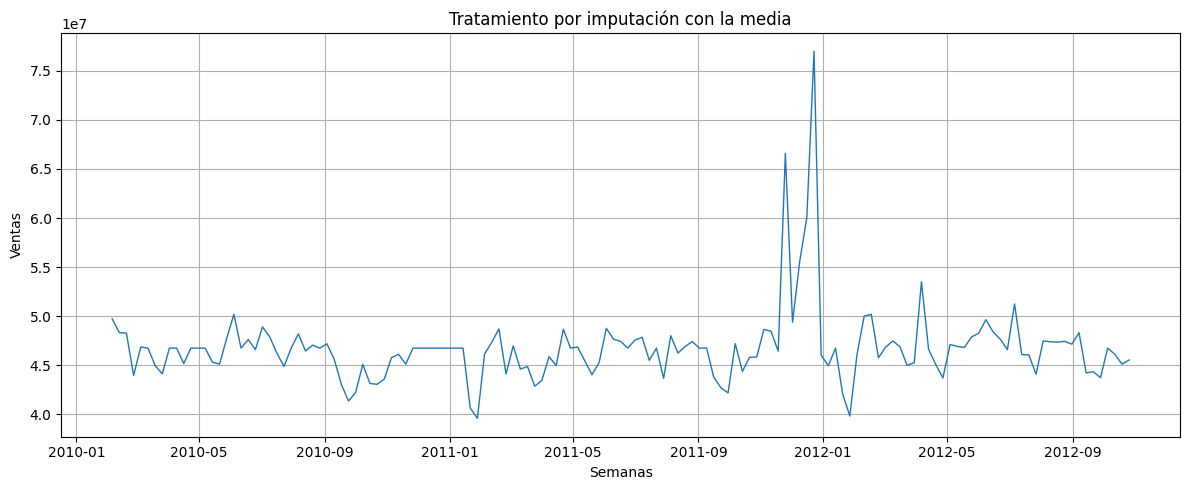

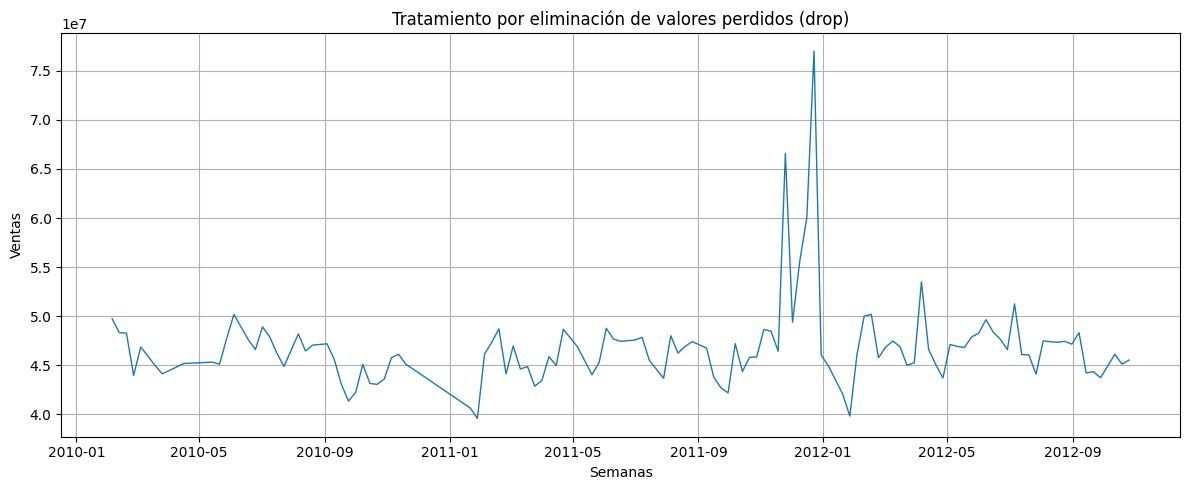

Resumen:
- Longitud original: 143
- NaN totales: 23
- Media usada para imputación: 46754242.6163
- Longitud tras eliminación: 120


In [25]:
SEMILLA = 701

# ============================================
# 1) Generar serie de prueba
# ============================================

np.random.seed(SEMILLA)
serie_missing = serie.copy() # Creamos una copia para después utilizar la original.

n = len(serie_missing)

# NaN en puntos aleatorios -
missing_idx = np.random.choice(n, size=15, replace=False)
serie_missing.iloc[missing_idx] = np.nan

# NaN en un segmento (bloque) - Semanas donde no se reportaron ventas
block_start = 42
block_end = 50

serie_missing.iloc[block_start:block_end] = np.nan

# ============================================
# 2) Método A: Imputación con la media
# ============================================

mean_value = serie_missing.mean(skipna=True)
serie_mean = serie_missing.fillna(mean_value)

# ============================================
# 3) Método B: Eliminación (drop)
# ============================================

serie_drop = serie_missing.dropna()

# ============================================
# 4) Gráficas
# ============================================
plt.figure(figsize=(12,5))
plt.plot(serie, linewidth=1)
plt.title("Serie original (sin valores perdidos)")
plt.xlabel("Semanas")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(serie_missing, linewidth=1)
plt.title("Serie con valores perdidos (NaN)")
plt.xlabel("Semanas")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(serie_mean, linewidth=1)
plt.title("Tratamiento por imputación con la media")
plt.xlabel("Semanas")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(serie_drop, linewidth=1)
plt.title("Tratamiento por eliminación de valores perdidos (drop)")
plt.xlabel("Semanas")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Resumen:")
print(f"- Longitud original: {len(serie)}")
print(f"- NaN totales: {serie_missing.isna().sum()}")
print(f"- Media usada para imputación: {mean_value:.4f}")
print(f"- Longitud tras eliminación: {len(serie_drop)}")

## Transformadas

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

Columna: Weekly_Sales
Longitud de la serie: 143
Min=39599852.9900, Max=80931415.6000


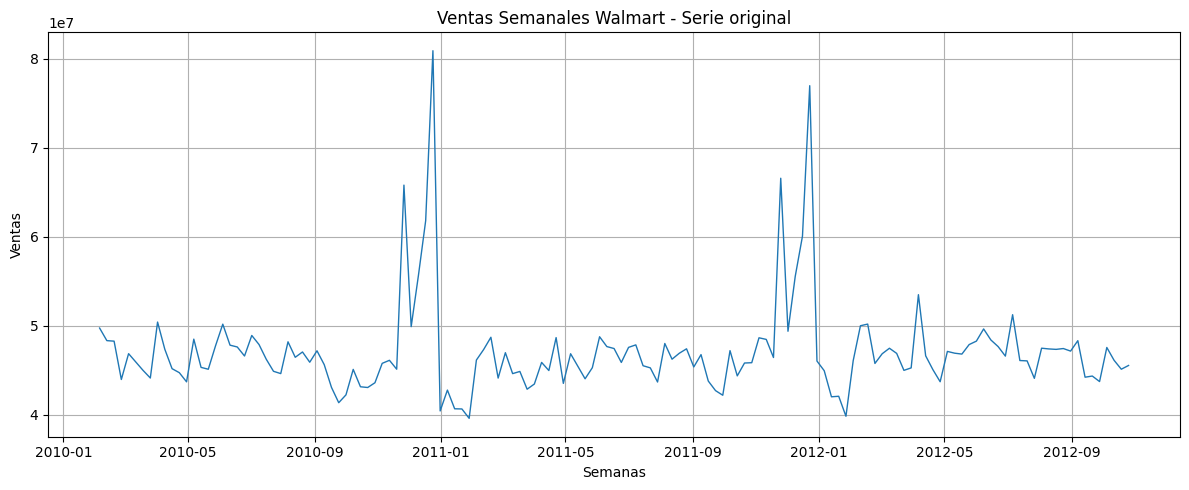

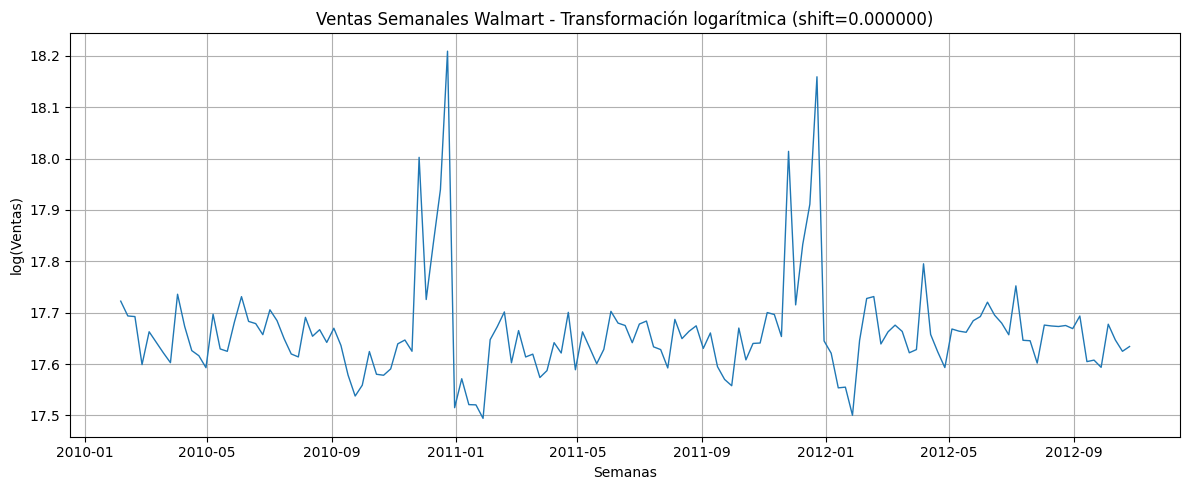

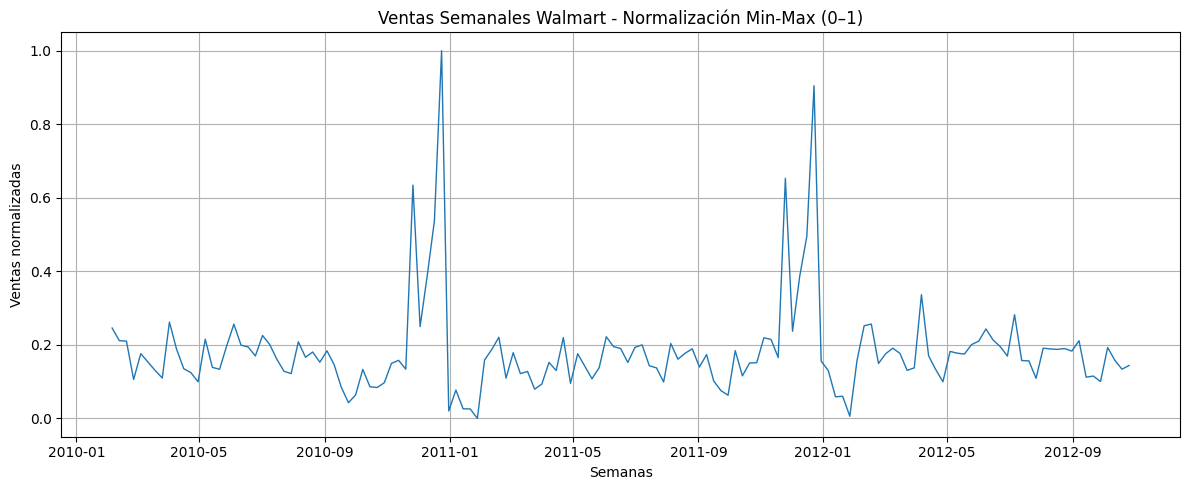

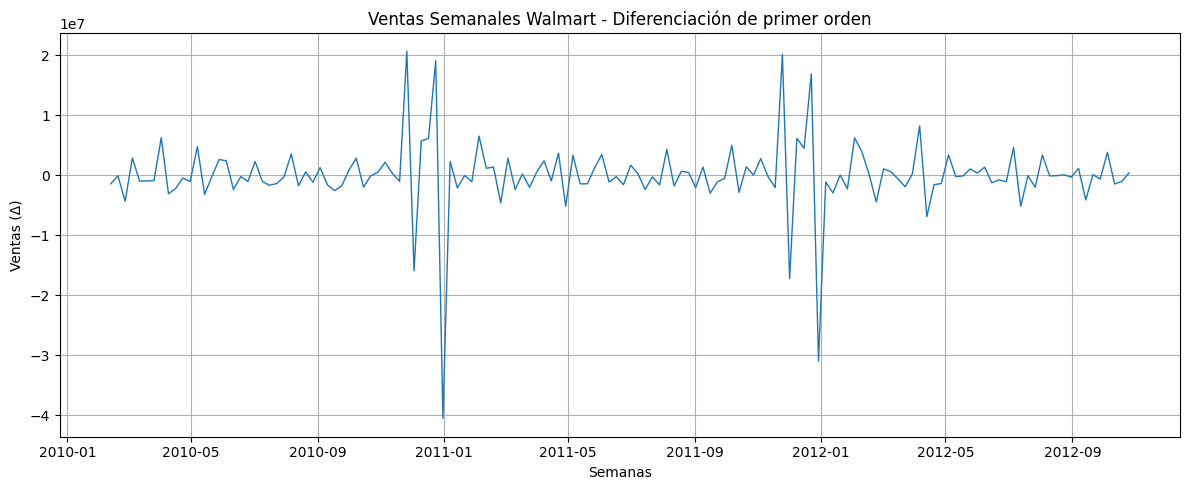

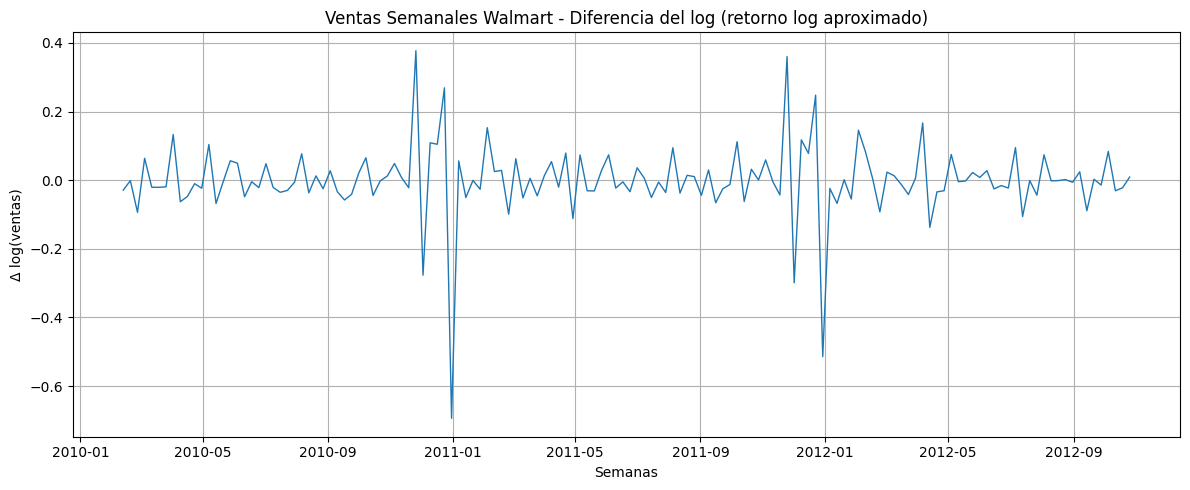

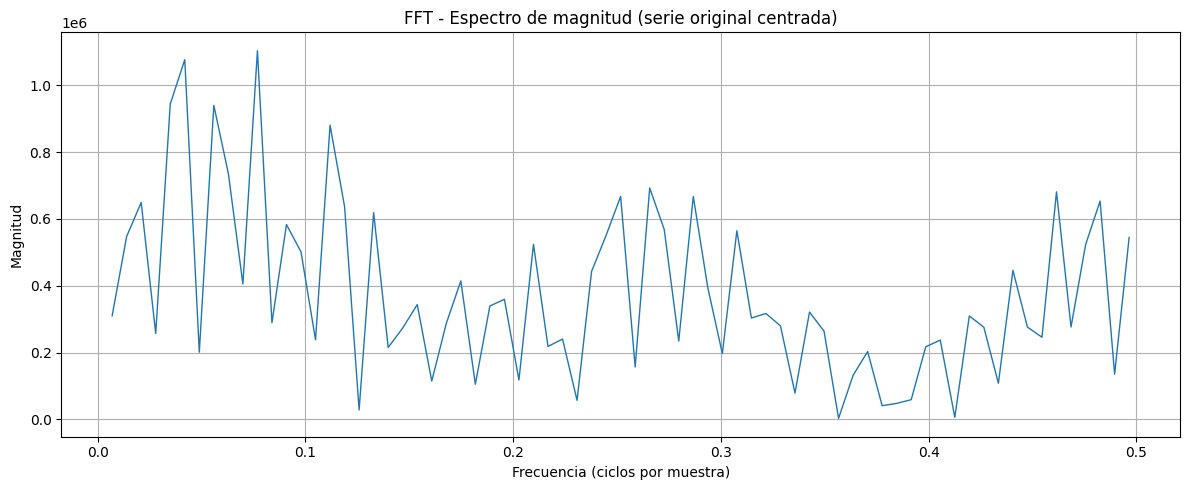

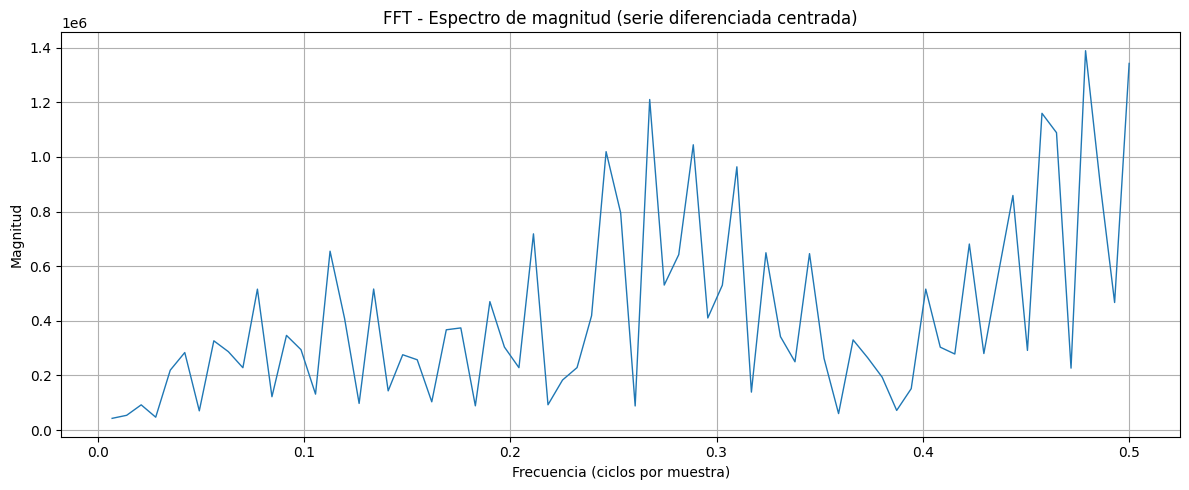


Top frecuencias dominantes (serie original centrada):
1) f=0.076923 -> periodo≈13.00 muestras, magnitud=1103281.718223
2) f=0.041958 -> periodo≈23.83 muestras, magnitud=1076480.712331
3) f=0.034965 -> periodo≈28.60 muestras, magnitud=943766.021277
4) f=0.055944 -> periodo≈17.88 muestras, magnitud=939851.014218
5) f=0.111888 -> periodo≈8.94 muestras, magnitud=880524.174894

Listo ✅ Se guardaron:
- ventas_walmart_transformaciones_fft.csv
- ventas_walmart_fft_spectrum.csv


In [38]:
# ================================================================
# 1) Tomamos nuestra serie de Ventas Semanales de Walmart
# ================================================================

serie_walmart = serie.copy()

print(f"Columna: {serie.name}")
print(f"Longitud de la serie: {len(serie_walmart)}")
print(f"Min={serie_walmart.min():.4f}, Max={serie_walmart.max():.4f}")

# ============================================
# 2) Transformación logarítmica
# ============================================

min_val = serie_walmart.min()
shift = 0.0
if min_val <= 0:
    shift = abs(min_val) + 1e-6

serie_log = np.log(serie_walmart + shift)
serie_log.name = "log(Ventas Semanales Walmart)"

# ============================================
# 3) Normalización (Min-Max 0–1)
# ============================================

scaler = MinMaxScaler(feature_range=(0, 1))
serie_norm = pd.Series(
    scaler.fit_transform(serie_walmart.values.reshape(-1, 1)).ravel(),
    index=serie_walmart.index,
    name="Ventas Semanales Walmart norm_0_1"
)

# ============================================
# 4) Diferenciación (1er orden)
# ============================================

serie_diff = serie_walmart.diff(1).dropna()
serie_diff.name = "diff(Ventas Semanales Walmart)"

serie_log_diff = serie_log.diff(1).dropna()
serie_log_diff.name = "diff(log(Ventas Semanales Walmart))"

# ============================================
# 5) FFT (Transformada de Fourier)
#    Recomendación: quitar la media para evitar que el "DC" domine.
# ============================================
def fft_spectrum(x: np.ndarray, dt: float = 1.0):
    """
    Retorna frecuencias positivas y magnitud normalizada del espectro FFT.
    dt: intervalo de muestreo (si es 1 muestra por unidad de tiempo, dt=1.0)
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)  # centrar
    n = len(x)

    X = np.fft.rfft(x)                 # FFT real (solo frecuencias >= 0)
    freqs = np.fft.rfftfreq(n, d=dt)   # vector de frecuencias
    mag = np.abs(X) / n                # magnitud normalizada

    return freqs, mag

# FFT sobre serie original centrada
freqs, mag = fft_spectrum(serie_walmart.values, dt=1.0)

# FFT sobre la serie diferenciada (suele mostrar mejor los ciclos)
freqs_d, mag_d = fft_spectrum(serie_diff.values, dt=1.0)

# Para evitar el pico en frecuencia 0 (DC) al graficar, lo removemos visualmente

mask_nonzero = freqs > 0
mask_nonzero_d = freqs_d > 0

# ============================================
# 6) Gráficas de series
# ============================================

plt.figure(figsize=(12, 5))
plt.plot(serie_walmart, linewidth=1)
plt.title("Ventas Semanales Walmart - Serie original")
plt.xlabel("Semanas")
plt.ylabel("Ventas")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(serie_log, linewidth=1)
plt.title(f"Ventas Semanales Walmart - Transformación logarítmica (shift={shift:.6f})")
plt.xlabel("Semanas")
plt.ylabel("log(Ventas)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(serie_norm, linewidth=1)
plt.title("Ventas Semanales Walmart - Normalización Min-Max (0–1)")
plt.xlabel("Semanas")
plt.ylabel("Ventas normalizadas")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(serie_diff, linewidth=1)
plt.title("Ventas Semanales Walmart - Diferenciación de primer orden")
plt.xlabel("Semanas")
plt.ylabel("Ventas (Δ)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(serie_log_diff, linewidth=1)
plt.title("Ventas Semanales Walmart - Diferencia del log (retorno log aproximado)")
plt.xlabel("Semanas")
plt.ylabel("Δ log(ventas)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# 7) Gráficas FFT
# ============================================
plt.figure(figsize=(12, 5))
plt.plot(freqs[mask_nonzero], mag[mask_nonzero], linewidth=1)
plt.title("FFT - Espectro de magnitud (serie original centrada)")
plt.xlabel("Frecuencia (ciclos por muestra)")
plt.ylabel("Magnitud")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(freqs_d[mask_nonzero_d], mag_d[mask_nonzero_d], linewidth=1)
plt.title("FFT - Espectro de magnitud (serie diferenciada centrada)")
plt.xlabel("Frecuencia (ciclos por muestra)")
plt.ylabel("Magnitud")
plt.grid(True)
plt.tight_layout()
plt.show()

# (Opcional) Mostrar los periodos dominantes aproximados (top 5)
# Evitamos freqs = 0
top_k = 5
idx_sorted = np.argsort(mag[mask_nonzero])[::-1][:top_k]
top_freqs = freqs[mask_nonzero][idx_sorted]
top_mags = mag[mask_nonzero][idx_sorted]
top_periods = 1 / top_freqs

print("\nTop frecuencias dominantes (serie original centrada):")
for i, (f, m, p) in enumerate(zip(top_freqs, top_mags, top_periods), 1):
    print(f"{i}) f={f:.6f} -> periodo≈{p:.2f} muestras, magnitud={m:.6f}")

# ============================================
# 8) Guardar resultados (opcional)
# ============================================
out = pd.DataFrame({
    "original": serie_walmart,
    "log": serie_log,
    "norm_0_1": serie_norm
})
out["diff1"] = serie_walmart.diff(1)
out["log_diff1"] = serie_log.diff(1)
out.to_csv("ventas_walmart_transformaciones_fft.csv", index=True)

fft_df = pd.DataFrame({
    "freq": freqs,
    "mag": mag
})
fft_df.to_csv("ventas_walmart_fft_spectrum.csv", index=False)

print("\nListo ✅ Se guardaron:")
print("- ventas_walmart_transformaciones_fft.csv")
print("- ventas_walmart_fft_spectrum.csv")

## Implementación de un Modelo SARIMA

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
import time
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

CARGANDO DATOS Ventas Semanales Walmart
Longitud de la serie: 143
Datos de Entrenamiento: 114
Datos de Prueba: 29

ENTRENANDO MODELO SARIMA
Modelo: SARIMA(1, 1, 1)(1, 1, 1)[13] | trend='n'
✓ Modelo entrenado en 0.12 segundos

EVALUANDO MODELO

★ MÉTRICAS FINALES:
--------------------------------------------------
IN-SAMPLE (Entrenamiento):
  MSE: 79177223540046.406250 (4.63%)
  RMSE: 8898158.435319 (21.53%)
  MAE: 5361878.615294
  SMAPE: 11.36%
  R²: -1.1932
  AIC: 3658.31
  BIC: 3671.99

OUT-OF-SAMPLE (Prueba):
  MSE: 31556319670194.410156 (55.56%)
  RMSE: 5617501.194499 (74.54%)
  MAE: 4481255.678801
  SMAPE: 8.96%
  R²: -9.5345
  AIC: 911.40
  BIC: 918.24

GENERANDO VISUALIZACIONES


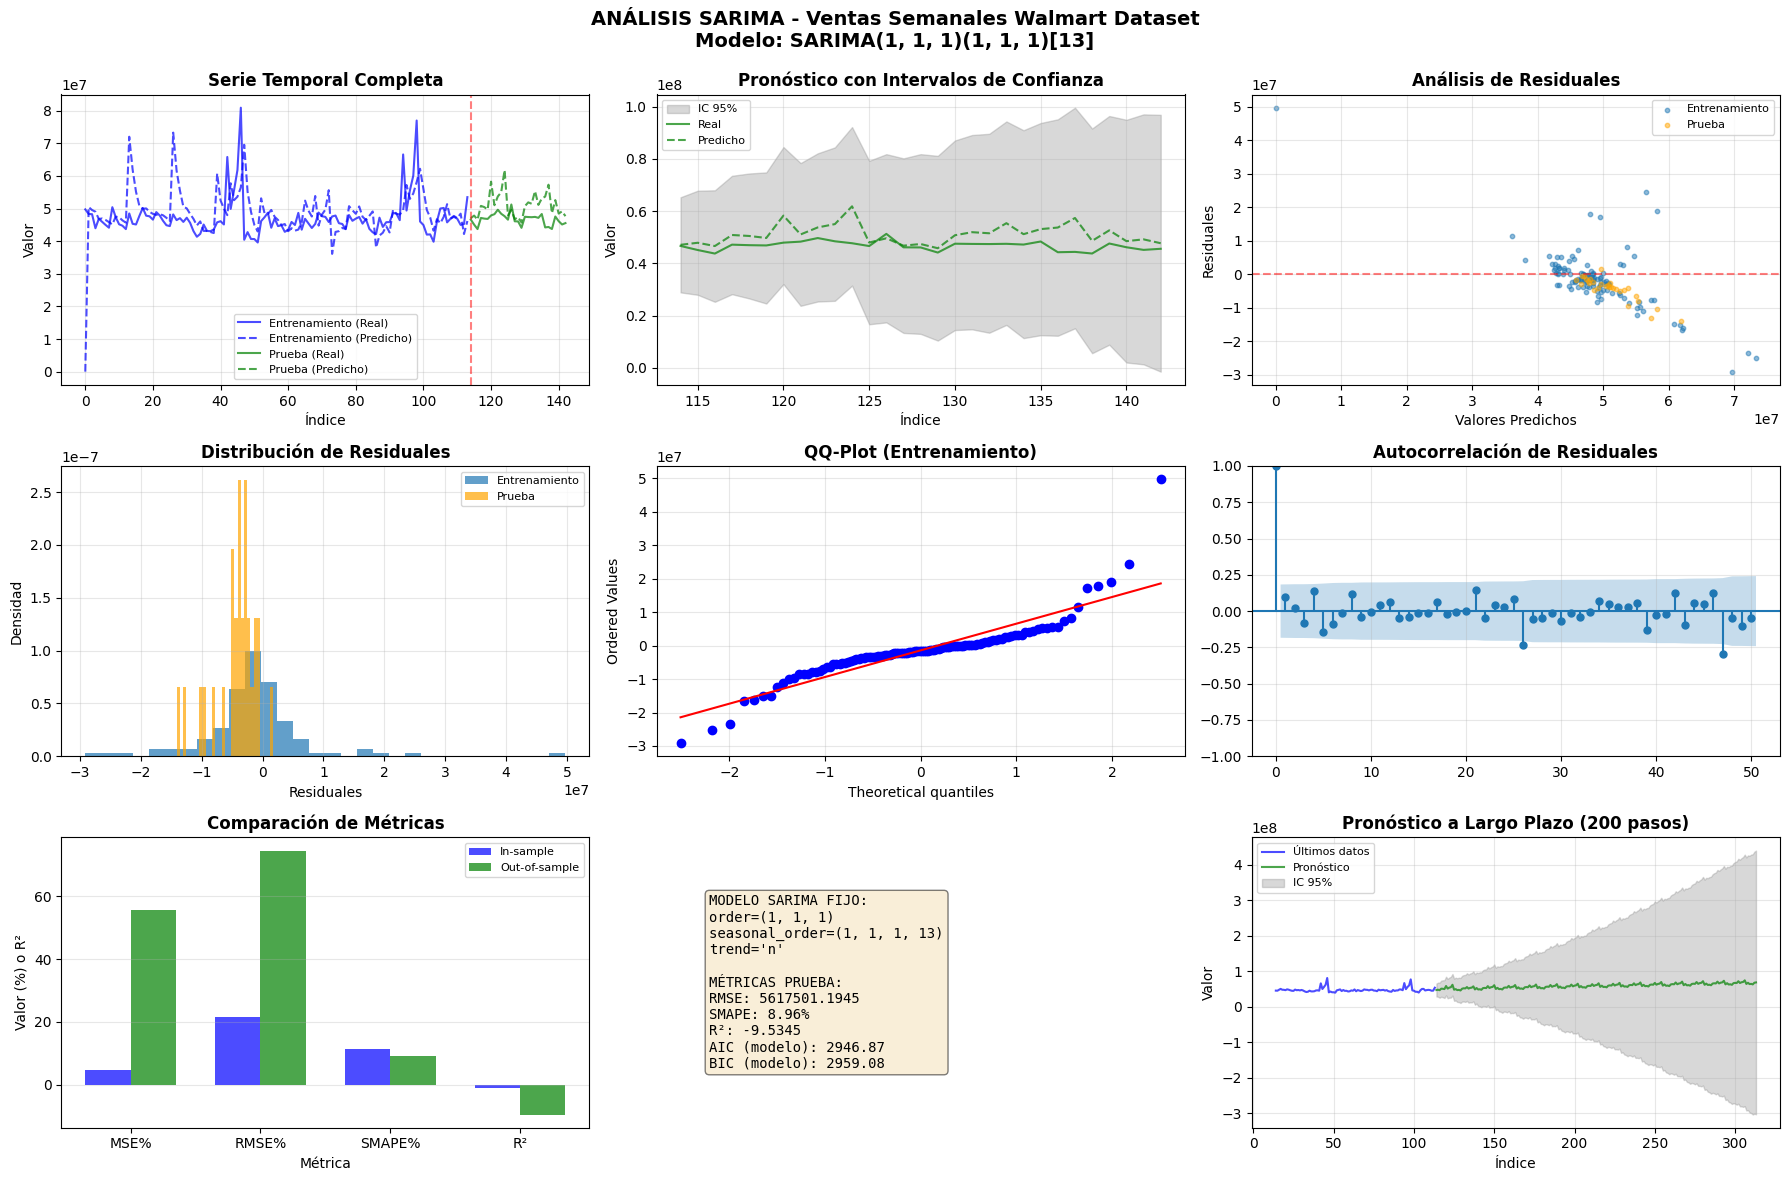

✓ Visualizaciones guardadas en 'sarima_VentasWalmart_analysis_fixed.png'

GUARDANDO RESULTADOS
✓ Modelo guardado en 'sarima_VentasWalmart_fixed_model.pkl'
✓ Métricas guardadas en 'sarima_ventasWalmart_fixed_metrics.txt'

¡PROCESO COMPLETADO EXITOSAMENTE!


In [14]:
warnings.filterwarnings("ignore")

# ============================================================
# CONFIGURACIÓN DEL MODELO SARIMA(1,1,3)(2,1,1)[13]
# ============================================================

ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 13)
TREND = 'n' # 'n' (ninguno), 'c' (constante), 't' (tendencia lineal), 'ct' (constante + tendencia)

# ============================================================
# 1. CARGAR DATOS - Ventas Semanales Walmart
# ============================================================
print("=" * 60)
print("CARGANDO DATOS Ventas Semanales Walmart")
print("=" * 60)

# Volvemos a cargar el dataset del csv y transformamos en serie.
dataset = pd.read_csv("Walmart_Sales.csv")

dataset["Date"] = pd.to_datetime(dataset["Date"], dayfirst=True)

# Agrupamos por semana y sumamos las ventas
serie = dataset.groupby("Date")["Weekly_Sales"].sum().sort_index()

print(f"Longitud de la serie: {len(serie)}")

# Dado que en la página donde descargue el dataset no estaba dividido en train y test.
# Haremos una división de los datos de forma manual.

# ============================================================
# 2. DIVIDIR EN TRAIN Y TEST
# ============================================================
# Vamos a usar 80% de los datos para entrenamiento y 20% para prueba
train_size = int(len(serie) * 0.8)
y_train = serie.iloc[:train_size]
y_test = serie.iloc[train_size:]

#idx_train = pd.RangeIndex(1, len(y_train) + 1)
#idx_test = pd.RangeIndex(len(y_train) + 1, len(y_train) + len(y_test) + 1)

print(f"Datos de Entrenamiento: {len(y_train)}")
print(f"Datos de Prueba: {len(y_test)}")

y_train_series = y_train.copy() # No es necesario modificar los indices
y_test_series = y_test.copy() # No es necesario modificar los indices

# ============================================================
# 3. FUNCIONES DE UTILIDAD
# ============================================================
def calcular_metricas(y_real, y_pred, n_params=0, dataset_name=""):
    """Calcula métricas de evaluación para series temporales"""
    y_real = np.array(y_real).flatten()
    y_pred = np.array(y_pred).flatten()

    min_len = min(len(y_real), len(y_pred))
    y_real = y_real[:min_len]
    y_pred = y_pred[:min_len]

    n = len(y_real)

    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)

    smape = 100 * np.mean(2 * np.abs(y_pred - y_real) / (np.abs(y_real) + np.abs(y_pred) + 1e-10))

    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + 1e-10))

    aic = bic = np.nan
    if n_params > 0 and n > 0:
        aic = n * np.log(mse) + 2 * n_params
        bic = n * np.log(mse) + n_params * np.log(n)

    data_range = np.max(y_real) - np.min(y_real)
    mse_percent = 100 * mse / (data_range ** 2 + 1e-10) if data_range > 0 else 0
    rmse_percent = 100 * rmse / data_range if data_range > 0 else 0

    return {
        f'MSE_{dataset_name}': mse,
        f'MSE_{dataset_name}_%': mse_percent,
        f'RMSE_{dataset_name}': rmse,
        f'RMSE_{dataset_name}_%': rmse_percent,
        f'MAE_{dataset_name}': mae,
        f'SMAPE_{dataset_name}_%': smape,
        f'R2_{dataset_name}': r2,
        f'AIC_{dataset_name}': aic,
        f'BIC_{dataset_name}': bic,
        f'n_{dataset_name}': n
    }

def forecast_sarima(modelo, y_train, steps):
    """Genera pronóstico con SARIMA"""
    try:
        fc = modelo.get_forecast(steps=steps)
        mean = fc.predicted_mean
        ci = fc.conf_int(alpha=0.05)
        low, up = ci.iloc[:, 0], ci.iloc[:, 1]

        idx_future = pd.RangeIndex(len(y_train) + 1, len(y_train) + 1 + steps)
        mean.index = idx_future
        low.index = idx_future
        up.index = idx_future

        return mean, low, up
    except Exception as e:
        print(f"Error en forecast: {e}")
        idx_future = pd.RangeIndex(len(y_train) + 1, len(y_train) + 1 + steps)
        mean = pd.Series([np.nan] * steps, index=idx_future)
        low = pd.Series([np.nan] * steps, index=idx_future)
        up = pd.Series([np.nan] * steps, index=idx_future)
        return mean, low, up

# ============================================================
# 4. ENTRENAR MODELO SARIMA
# ============================================================
print("\n" + "=" * 60)
print("ENTRENANDO MODELO SARIMA")
print("=" * 60)

print(f"Modelo: SARIMA{ORDER}{SEASONAL_ORDER[:-1]}[{SEASONAL_ORDER[-1]}] | trend='{TREND}'")

start_time_final = time.time()

modelo_final = SARIMAX(
    y_train_series,
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    trend=TREND,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=100)

training_time_final = time.time() - start_time_final
print(f"✓ Modelo entrenado en {training_time_final:.2f} segundos")

# ============================================================
# 5. PREDICCIONES Y MÉTRICAS
# ============================================================
print("\n" + "=" * 60)
print("EVALUANDO MODELO")
print("=" * 60)

# In-sample
y_train_pred = modelo_final.fittedvalues

#min_len_train = min(len(y_train_series), len(y_train_pred))
train_df = pd.concat([y_train_series, y_train_pred], axis=1)
train_df.columns = ['real', 'pred']
train_df = train_df.dropna()

y_train_actual = train_df['real'].values
y_train_pred_vals = train_df['pred'].values

# Out-of-sample
y_test_pred, y_test_low, y_test_up = forecast_sarima(modelo_final, y_train_series, len(y_test_series))

n_params = len(modelo_final.params)

metrics_in = calcular_metricas(y_train_actual, y_train_pred_vals, n_params, "in")
metrics_out = calcular_metricas(y_test_series.values, y_test_pred.values, n_params, "out")

print("\n★ MÉTRICAS FINALES:")
print("-" * 50)
print("IN-SAMPLE (Entrenamiento):")
print(f"  MSE: {metrics_in['MSE_in']:.6f} ({metrics_in['MSE_in_%']:.2f}%)")
print(f"  RMSE: {metrics_in['RMSE_in']:.6f} ({metrics_in['RMSE_in_%']:.2f}%)")
print(f"  MAE: {metrics_in['MAE_in']:.6f}")
print(f"  SMAPE: {metrics_in['SMAPE_in_%']:.2f}%")
print(f"  R²: {metrics_in['R2_in']:.4f}")
print(f"  AIC: {metrics_in['AIC_in']:.2f}")
print(f"  BIC: {metrics_in['BIC_in']:.2f}")

print("\nOUT-OF-SAMPLE (Prueba):")
print(f"  MSE: {metrics_out['MSE_out']:.6f} ({metrics_out['MSE_out_%']:.2f}%)")
print(f"  RMSE: {metrics_out['RMSE_out']:.6f} ({metrics_out['RMSE_out_%']:.2f}%)")
print(f"  MAE: {metrics_out['MAE_out']:.6f}")
print(f"  SMAPE: {metrics_out['SMAPE_out_%']:.2f}%")
print(f"  R²: {metrics_out['R2_out']:.4f}")
print(f"  AIC: {metrics_out['AIC_out']:.2f}")
print(f"  BIC: {metrics_out['BIC_out']:.2f}")

# ============================================================
# 6. VISUALIZACIONES
# ============================================================
print("\n" + "=" * 60)
print("GENERANDO VISUALIZACIONES")
print("=" * 60)

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Serie completa
ax1 = axes[0, 0]
ax1.plot(np.arange(len(y_train_actual)), y_train_actual, 'b-', alpha=0.7, label='Entrenamiento (Real)')
ax1.plot(np.arange(len(y_train_actual)), y_train_pred_vals, 'b--', alpha=0.7, label='Entrenamiento (Predicho)')
ax1.plot(np.arange(len(y_train_actual), len(y_train_actual) + len(y_test_series)),
         y_test_series.values, 'g-', alpha=0.7, label='Prueba (Real)')
ax1.plot(np.arange(len(y_train_actual), len(y_train_actual) + len(y_test_series)),
         y_test_pred.values, 'g--', alpha=0.7, label='Prueba (Predicho)')
ax1.axvline(x=len(y_train_actual), color='r', linestyle='--', alpha=0.5)
ax1.set_title('Serie Temporal Completa', fontweight='bold')
ax1.set_xlabel('Índice')
ax1.set_ylabel('Valor')
ax1.legend(loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Intervalos de confianza (prueba)
ax2 = axes[0, 1]
test_idx = np.arange(len(y_train_actual), len(y_train_actual) + len(y_test_series))
ax2.fill_between(test_idx, y_test_low.values, y_test_up.values, alpha=0.3, color='gray', label='IC 95%')
ax2.plot(test_idx, y_test_series.values, 'g-', alpha=0.7, label='Real')
ax2.plot(test_idx, y_test_pred.values, 'g--', alpha=0.7, label='Predicho')
ax2.set_title('Pronóstico con Intervalos de Confianza', fontweight='bold')
ax2.set_xlabel('Índice')
ax2.set_ylabel('Valor')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Residuales
ax3 = axes[0, 2]
residuales_train = y_train_actual - y_train_pred_vals
residuales_test = y_test_series.values - y_test_pred.values
ax3.scatter(y_train_pred_vals, residuales_train, alpha=0.5, s=10, label='Entrenamiento')
ax3.scatter(y_test_pred.values, residuales_test, alpha=0.5, s=10, color='orange', label='Prueba')
ax3.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax3.set_title('Análisis de Residuales', fontweight='bold')
ax3.set_xlabel('Valores Predichos')
ax3.set_ylabel('Residuales')
ax3.legend(loc='best', fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. Histograma de residuales
ax4 = axes[1, 0]
ax4.hist(residuales_train, bins=30, alpha=0.7, density=True, label='Entrenamiento')
ax4.hist(residuales_test, bins=30, alpha=0.7, density=True, color='orange', label='Prueba')
ax4.set_title('Distribución de Residuales', fontweight='bold')
ax4.set_xlabel('Residuales')
ax4.set_ylabel('Densidad')
ax4.legend(loc='best', fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. QQ-Plot de residuales
ax5 = axes[1, 1]
stats.probplot(residuales_train, dist="norm", plot=ax5)
ax5.set_title('QQ-Plot (Entrenamiento)', fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Autocorrelación de residuales
ax6 = axes[1, 2]
plot_acf(residuales_train, lags=50, ax=ax6, alpha=0.05)
ax6.set_title('Autocorrelación de Residuales', fontweight='bold')
ax6.grid(True, alpha=0.3)

# 7. Comparación de métricas
ax7 = axes[2, 0]
metricas_nombres = ['MSE%', 'RMSE%', 'SMAPE%', 'R²']
valores_in = [metrics_in['MSE_in_%'], metrics_in['RMSE_in_%'],
              metrics_in['SMAPE_in_%'], metrics_in['R2_in']]
valores_out = [metrics_out['MSE_out_%'], metrics_out['RMSE_out_%'],
               metrics_out['SMAPE_out_%'], metrics_out['R2_out']]

x = np.arange(len(metricas_nombres))
ancho = 0.35
ax7.bar(x - ancho/2, valores_in, ancho, label='In-sample', alpha=0.7, color='blue')
ax7.bar(x + ancho/2, valores_out, ancho, label='Out-of-sample', alpha=0.7, color='green')
ax7.set_xlabel('Métrica')
ax7.set_ylabel('Valor (%) o R²')
ax7.set_title('Comparación de Métricas', fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(metricas_nombres)
ax7.legend(loc='best', fontsize=8)
ax7.grid(True, alpha=0.3, axis='y')

# 8. Parámetros del modelo
ax8 = axes[2, 1]
ax8.axis('off')
info_text = "MODELO SARIMA FIJO:\n"
info_text += f"order={ORDER}\nseasonal_order={SEASONAL_ORDER}\ntrend='{TREND}'\n"
info_text += "\nMÉTRICAS PRUEBA:\n"
info_text += f"RMSE: {metrics_out['RMSE_out']:.4f}\n"
info_text += f"SMAPE: {metrics_out['SMAPE_out_%']:.2f}%\n"
info_text += f"R²: {metrics_out['R2_out']:.4f}\n"
info_text += f"AIC (modelo): {modelo_final.aic:.2f}\n"
info_text += f"BIC (modelo): {modelo_final.bic:.2f}"
ax8.text(0.1, 0.5, info_text, fontsize=10, verticalalignment='center',
         family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 9. Pronóstico a largo plazo
ax9 = axes[2, 2]
h_largo = 200
y_largo_pred, y_largo_low, y_largo_up = forecast_sarima(modelo_final, y_train_series, h_largo)

ultimos = 100
inicio_grafico = max(len(y_train_series) - ultimos, 0)
idx_train_plot = np.arange(inicio_grafico, len(y_train_series))
idx_largo_plot = np.arange(len(y_train_series), len(y_train_series) + h_largo)

ax9.plot(idx_train_plot, y_train_series.values[inicio_grafico:], 'b-', alpha=0.7, label='Últimos datos')
ax9.plot(idx_largo_plot, y_largo_pred.values, 'g-', alpha=0.7, label='Pronóstico')
ax9.fill_between(idx_largo_plot, y_largo_low.values, y_largo_up.values,
                 alpha=0.3, color='gray', label='IC 95%')
ax9.set_title(f'Pronóstico a Largo Plazo ({h_largo} pasos)', fontweight='bold')
ax9.set_xlabel('Índice')
ax9.set_ylabel('Valor')
ax9.legend(loc='best', fontsize=8)
ax9.grid(True, alpha=0.3)

fig.suptitle(
    "ANÁLISIS SARIMA - Ventas Semanales Walmart Dataset\n"
    f"Modelo: SARIMA{ORDER}{SEASONAL_ORDER[:-1]}[{SEASONAL_ORDER[-1]}]",
    fontsize=14, fontweight='bold', y=0.98
)

plt.tight_layout()
plt.savefig('sarima_VentasWalmart_analysis_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualizaciones guardadas en 'sarima_VentasWalmart_analysis_fixed.png'")

# ============================================================
# 6. GUARDAR RESULTADOS
# ============================================================
print("\n" + "=" * 60)
print("GUARDANDO RESULTADOS")
print("=" * 60)

joblib.dump(modelo_final, 'sarima_VentasWalmart_fixed_model.pkl')
print("✓ Modelo guardado en 'sarima_VentasWalmart_fixed_model.pkl'")

with open('sarima_ventasWalmart_fixed_metrics.txt', 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("RESULTADOS SARIMA\n")
    f.write("=" * 60 + "\n\n")

    f.write("MODELO UTILIZADO:\n")
    f.write("-" * 40 + "\n")
    f.write(f"order={ORDER}\n")
    f.write(f"seasonal_order={SEASONAL_ORDER}\n")
    f.write(f"trend='{TREND}'\n")
    f.write(f"AIC (modelo): {modelo_final.aic:.6f}\n")
    f.write(f"BIC (modelo): {modelo_final.bic:.6f}\n\n")

    f.write("MÉTRICAS IN-SAMPLE (Entrenamiento):\n")
    f.write("-" * 40 + "\n")
    for key, value in metrics_in.items():
        if 'n_' not in key:
            f.write(f"{key}: {value:.6f}\n")
    f.write("\n")

    f.write("MÉTRICAS OUT-OF-SAMPLE (Prueba):\n")
    f.write("-" * 40 + "\n")
    for key, value in metrics_out.items():
        if 'n_' not in key:
            f.write(f"{key}: {value:.6f}\n")
    f.write("\n")

print("✓ Métricas guardadas en 'sarima_ventasWalmart_fixed_metrics.txt'")

print("\n" + "=" * 60)
print("¡PROCESO COMPLETADO EXITOSAMENTE!")
print("=" * 60)

## Implementación de la ARnet

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import time
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor

from statsmodels.tsa.stattools import acf
from statsmodels.graphics.gofplots import qqplot
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf

CARGANDO DATOS Ventas Semanales Walmart
Longitud de la serie: 143
Datos de Entrenamiento: (114, 1)
Datos de Prueba: (29, 1)

Después de diferenciación:
Entrenamiento: (113, 1)
Prueba: (28, 1)

Datos con retrasos:
  Train X: (100, 3) | Train y: (100, 1)
  Test  X: (15, 3) | Test  y: (15, 1)

Entrenando modelo ARNet (MLPRegressor)...
Entrenamiento completado en 0.03 s
Número de parámetros (calculado): 231


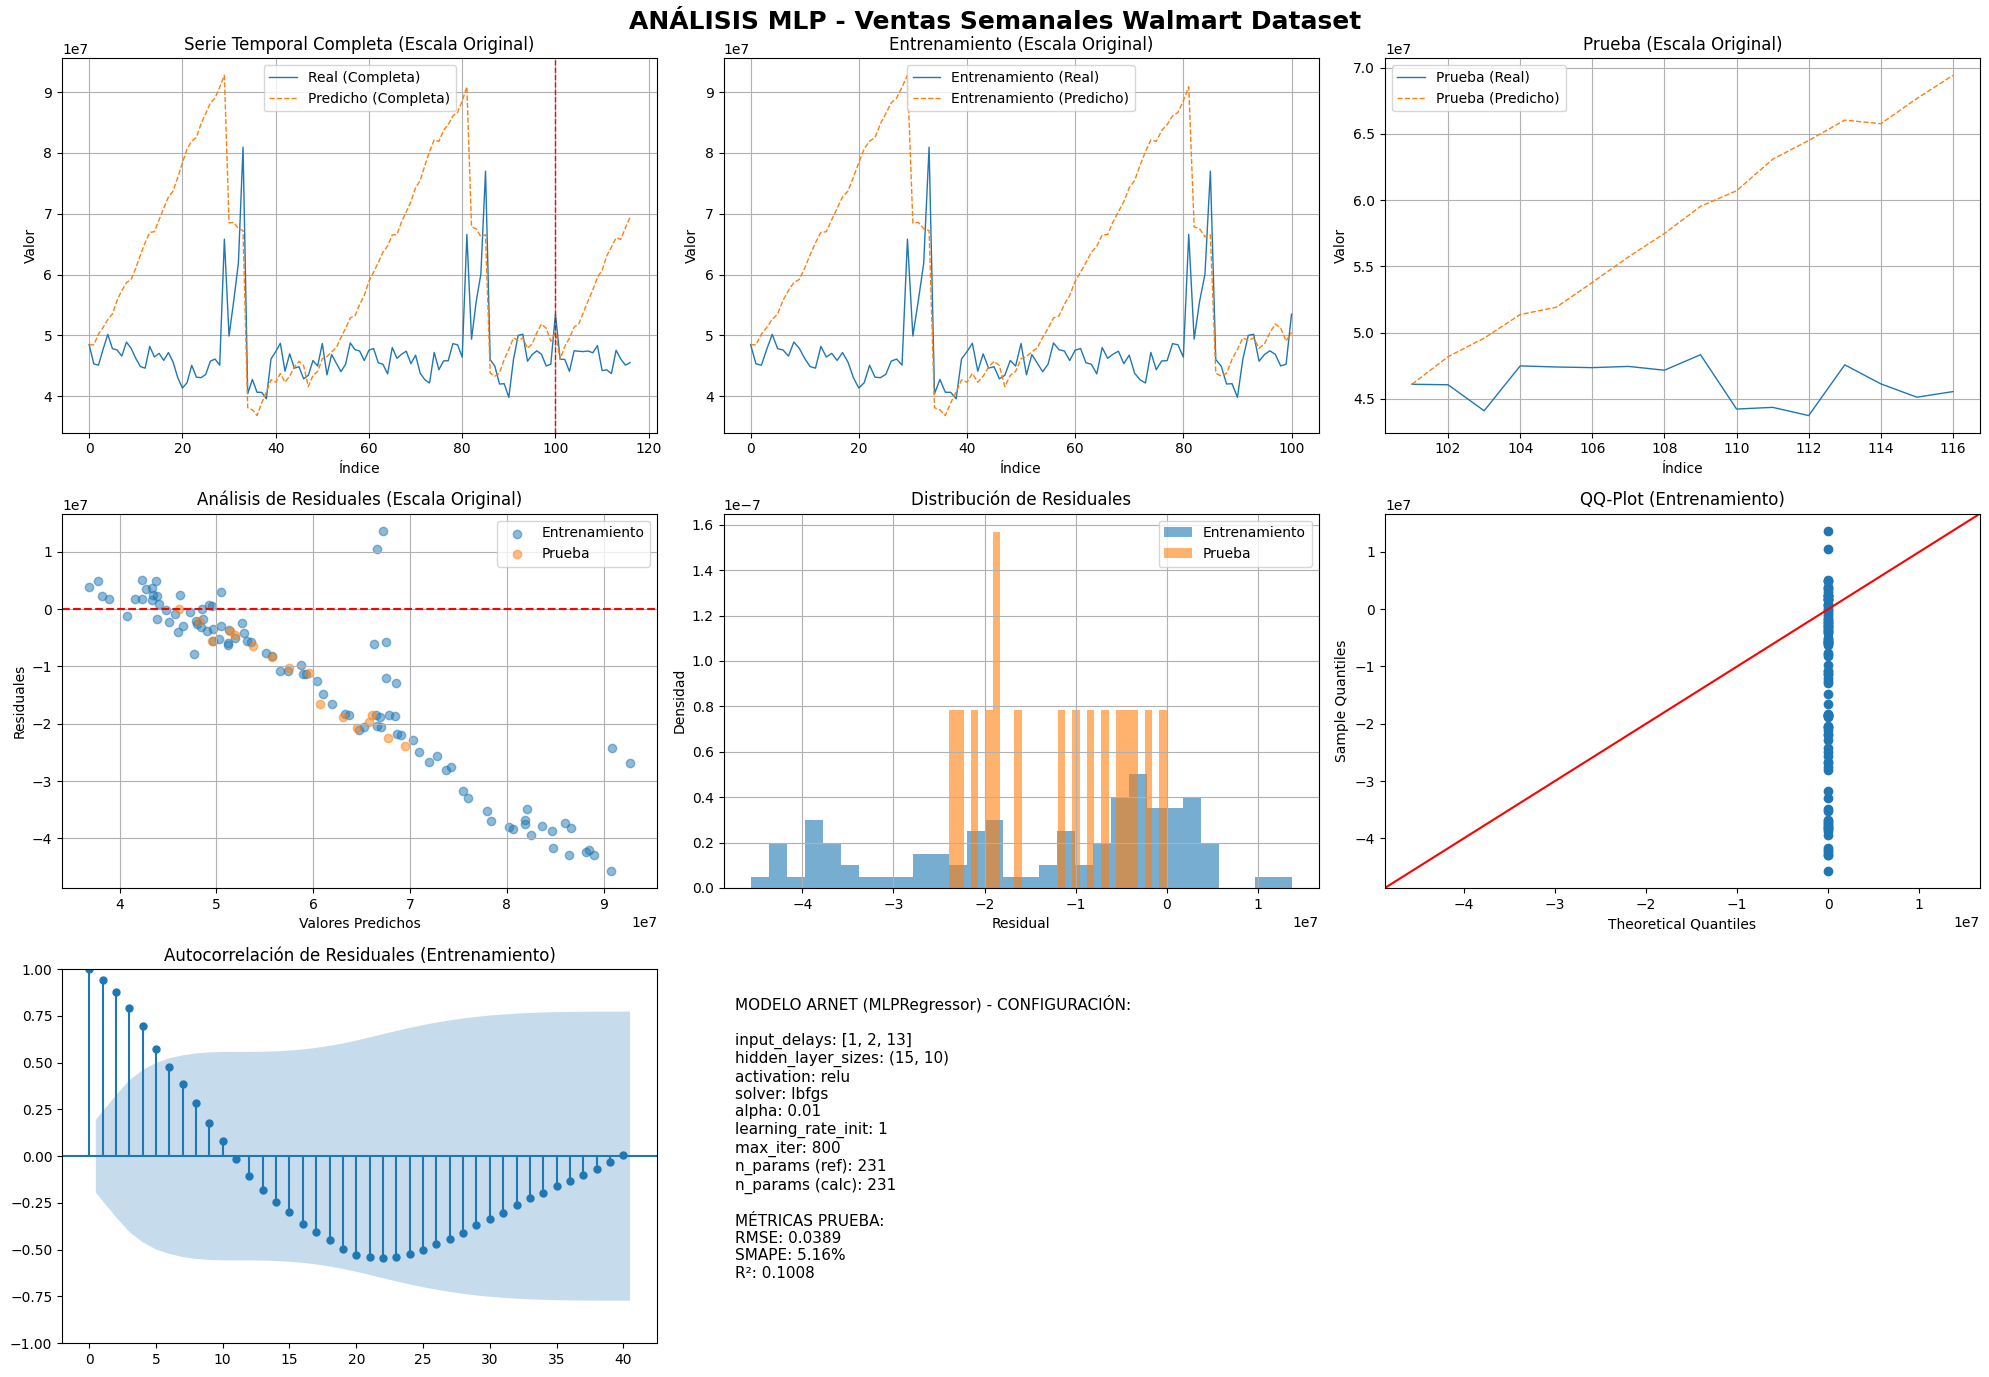


Modelo guardado: arnet_model_fixed.pkl
Scaler guardado: arnet_scaler_fixed.pkl
Métricas guardadas: arnet_model_metrics_fixed.txt

Listo.


In [30]:
warnings.filterwarnings("ignore")

# ============================
# 1) CARGAR DATOS DE CSV
# ============================
SEMILLA = 701

print("=" * 60)
print("CARGANDO DATOS Ventas Semanales Walmart")
print("=" * 60)

# Volvemos a cargar el dataset del csv y transformamos en serie.
dataset = pd.read_csv("Walmart_Sales.csv")

dataset["Date"] = pd.to_datetime(dataset["Date"], dayfirst=True)

# Agrupamos por semana y sumamos las ventas
serie = (
    dataset.groupby("Date")["Weekly_Sales"]
    .sum()
    .sort_index()
    .values
    .reshape(-1, 1)
    .astype(float)
)

print(f"Longitud de la serie: {len(serie)}")

# Dado que en la página donde descargue el dataset no estaba dividido en train y test.
# Haremos una división de los datos de forma manual.

# ============================================================
# 2. DIVIDIR EN TRAIN Y TEST
# ============================================================
# Vamos a usar 80% de los datos para entrenamiento y 20% para prueba
split_index = int(len(serie) * 0.8)
X_train_raw = serie[:split_index]
X_test_raw  = serie[split_index:]

print(f"Datos de Entrenamiento: {X_train_raw.shape}")
print(f"Datos de Prueba: {X_test_raw.shape}")

# ============================================================
# 3) TRANSFORMACIONES: DIFERENCIACIÓN
# ============================================================
def apply_differencing(series: np.ndarray, order: int = 1) -> np.ndarray:
    """Aplica diferenciación de orden 'order' (1 por defecto)."""
    diff_series = series.copy()
    for _ in range(order):
        diff_series = np.diff(diff_series, axis=0)
    return diff_series

def reconstruct_series_from_diffs(diffs: np.ndarray, first_value: float) -> np.ndarray:
    """Reconstruye la serie original a partir de diferencias y el primer valor (y0)."""
    diffs = diffs.flatten()
    reconstructed = np.zeros(len(diffs) + 1, dtype=float)
    reconstructed[0] = float(first_value)
    for i in range(1, len(reconstructed)):
        reconstructed[i] = reconstructed[i - 1] + diffs[i - 1]
    return reconstructed

# Diferenciar
X_train_diff = apply_differencing(X_train_raw, order=1)
X_test_diff  = apply_differencing(X_test_raw, order=1)

first_value_train = float(X_train_raw[0].item())
first_value_test  = float(X_test_raw[0].item())

print("\nDespués de diferenciación:")
print(f"Entrenamiento: {X_train_diff.shape}")
print(f"Prueba: {X_test_diff.shape}")

# ============================================================
# 4) PREPARAR DATOS AUTOREGRESIVOS (INPUT DELAYS)
# ============================================================
def create_autoregressive_data(data: np.ndarray, delays: list[int], target: np.ndarray | None = None):
    """
    Crea dataset con retrasos temporales:
    X[t] = [x(t-d1), x(t-d2), ...]
    y[t] = target[t]
    """
    max_delay = max(delays)
    X_delayed = []

    for i in range(max_delay, len(data)):
        delayed_values = []
        for d in sorted(delays):
            delayed_values.extend(data[i - d])
        X_delayed.append(delayed_values)

    X_delayed = np.array(X_delayed, dtype=float)

    if target is not None:
        y = target[max_delay:]
        return X_delayed, y

    return X_delayed

# ============================================================
# 5) NORMALIZACIÓN
# ============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_diff)
X_test_scaled  = scaler.transform(X_test_diff)

T_train_scaled = X_train_scaled.copy()
T_test_scaled  = X_test_scaled.copy()

# ============================================================
# 6) MODELO
# ============================================================
fixed_params = {
    "input_delays": [1, 2, 13], # Hay estacionalidad de cada 13 semanas
    "hidden_layer_sizes": (15, 10), # Se cambia ya que el dataset de ventas es mas pequeño
    "activation": "relu",
    "solver": "lbfgs",
    "alpha": 0.01,
    "learning_rate_init": 1,
    "max_iter": 800,
}

# Preparar entrenamiento con retrasos
X_train_delayed, y_train = create_autoregressive_data(
    X_train_scaled, fixed_params["input_delays"], T_train_scaled
)

X_test_delayed, y_test = create_autoregressive_data(
    X_test_scaled, fixed_params["input_delays"], T_test_scaled
)

print("\nDatos con retrasos:")
print(f"  Train X: {X_train_delayed.shape} | Train y: {y_train.shape}")
print(f"  Test  X: {X_test_delayed.shape} | Test  y: {y_test.shape}")

# Entrenar MLPRegressor
arnet = MLPRegressor(
    hidden_layer_sizes=fixed_params["hidden_layer_sizes"],
    activation=fixed_params["activation"],
    solver=fixed_params["solver"],
    alpha=fixed_params["alpha"],
    learning_rate_init=fixed_params["learning_rate_init"],
    max_iter=fixed_params["max_iter"],
    random_state=SEMILLA,
    verbose=0
)

print("\nEntrenando modelo ARNet (MLPRegressor)...")
t0 = time.time()
arnet.fit(X_train_delayed, y_train.ravel())
train_time = time.time() - t0
print(f"Entrenamiento completado en {train_time:.2f} s")

# ============================================================
# 7) MÉTRICAS
# ============================================================
def calculate_metrics(y_true, y_pred, n_params, dataset_name=""):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    n = len(y_true)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)

    smape = 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-10)
    )

    corr = np.corrcoef(y_true, y_pred)
    r2 = float(corr[0, 1] ** 2) if np.isfinite(corr[0, 1]) else np.nan

    aic = n * np.log(mse + 1e-12) + 2 * n_params
    bic = n * np.log(mse + 1e-12) + n_params * np.log(max(n, 2))

    data_range = np.max(y_true) - np.min(y_true)
    mse_percent = 100 * mse / (data_range ** 2 + 1e-10)
    rmse_percent = 100 * rmse / (data_range + 1e-10)

    return {
        f"MSE_{dataset_name}": mse,
        f"MSE_{dataset_name}_%": mse_percent,
        f"RMSE_{dataset_name}": rmse,
        f"RMSE_{dataset_name}_%": rmse_percent,
        f"SMAPE_{dataset_name}_%": smape,
        f"R2_{dataset_name}_Pearson2": r2,
        f"AIC_{dataset_name}": aic,
        f"BIC_{dataset_name}": bic,
    }
# Número de parámetros real del MLP (calculado)
n_params_real = int(
    sum(np.prod(w.shape) for w in arnet.coefs_) + sum(np.prod(b.shape) for b in arnet.intercepts_)
)
print(f"Número de parámetros (calculado): {n_params_real}")

# Predicciones (en serie diferenciada-escalada)
y_train_pred = arnet.predict(X_train_delayed)
y_test_pred  = arnet.predict(X_test_delayed)

metrics_in  = calculate_metrics(y_train.ravel(), y_train_pred, n_params_real, "in")
metrics_out = calculate_metrics(y_test.ravel(),  y_test_pred,  n_params_real, "out")

# ============================
# 7) INVERTIR TRANSFORMACIONES PARA ANÁLISIS EN ESCALA ORIGINAL
# ============================
# Desescalar diferencias
y_train_true_descaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_train_pred_descaled = scaler.inverse_transform(y_train_pred.reshape(-1, 1)).flatten()

y_test_true_descaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_test_pred_descaled = scaler.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()

# Reconstrucción a serie original (ojo: por delays se pierde max_delay al inicio)
max_delay = max(fixed_params["input_delays"])

# Para que la reconstrucción sea consistente, necesitamos el valor "inicial" del punto donde empieza el target.
# Como y[t] corresponde a X_scaled[t], y empieza en índice max_delay, el valor inicial real es:
train_first_value_recon = float(X_train_raw[max_delay].item())
test_first_value_recon  = float(X_test_raw[max_delay].item())

train_series_true = reconstruct_series_from_diffs(y_train_true_descaled, train_first_value_recon)
train_series_pred = reconstruct_series_from_diffs(y_train_pred_descaled, train_first_value_recon)

test_series_true = reconstruct_series_from_diffs(y_test_true_descaled, test_first_value_recon)
test_series_pred = reconstruct_series_from_diffs(y_test_pred_descaled, test_first_value_recon)

# ============================
# 8) GRÁFICAS - ESCALA ORIGINAL
# ============================
# ----------------------------
# Construir ejes de índice
# ----------------------------
n_tr = len(train_series_true)
n_te = len(test_series_true)

idx_tr = np.arange(0, n_tr)
idx_te = np.arange(n_tr, n_tr + n_te)

# Para serie completa (concatenada)
series_true_full = np.concatenate([train_series_true, test_series_true])
series_pred_full = np.concatenate([train_series_pred, test_series_pred])
idx_full = np.arange(0, len(series_true_full))

# ----------------------------
# Residuales EN ESCALA ORIGINAL
# ----------------------------
res_train_orig = train_series_true - train_series_pred
res_test_orig  = test_series_true  - test_series_pred

# Métricas a mostrar (ya calculadas)
rmse_test  = metrics_out["RMSE_out"]
smape_test = metrics_out["SMAPE_out_%"]
r2_test    = metrics_out["R2_out_Pearson2"]

# ----------------------------
# Figura tipo dashboard (3x3)
# ----------------------------
fig = plt.figure(figsize=(20, 14))
plt.suptitle("ANÁLISIS MLP - Ventas Semanales Walmart Dataset", fontsize=18, fontweight="bold")

# ------------------------------------------------
# (1) Serie completa (original) + split marker
# ------------------------------------------------
ax1 = plt.subplot(3, 3, 1)
ax1.plot(idx_full, series_true_full, label="Real (Completa)", linewidth=1)
ax1.plot(idx_full, series_pred_full, label="Predicho (Completa)", linestyle="--", linewidth=1)
ax1.axvline(n_tr - 1, linestyle="--", color="red", linewidth=1)  # frontera train/test
ax1.set_title("Serie Temporal Completa (Escala Original)")
ax1.set_xlabel("Índice")
ax1.set_ylabel("Valor")
ax1.legend()
ax1.grid(True)

# ------------------------------------------------
# (2) Entrenamiento separado
# ------------------------------------------------
ax2 = plt.subplot(3, 3, 2)
ax2.plot(idx_tr, train_series_true, label="Entrenamiento (Real)", linewidth=1)
ax2.plot(idx_tr, train_series_pred, label="Entrenamiento (Predicho)", linestyle="--", linewidth=1)
ax2.set_title("Entrenamiento (Escala Original)")
ax2.set_xlabel("Índice")
ax2.set_ylabel("Valor")
ax2.legend()
ax2.grid(True)

# ------------------------------------------------
# (3) Prueba separado
# ------------------------------------------------
ax3 = plt.subplot(3, 3, 3)
ax3.plot(idx_te, test_series_true, label="Prueba (Real)", linewidth=1)
ax3.plot(idx_te, test_series_pred, label="Prueba (Predicho)", linestyle="--", linewidth=1)
ax3.set_title("Prueba (Escala Original)")
ax3.set_xlabel("Índice")
ax3.set_ylabel("Valor")
ax3.legend()
ax3.grid(True)

# ------------------------------------------------
# (4) Análisis de residuales (Predicho vs Residual) - ORIGINAL
# ------------------------------------------------
ax4 = plt.subplot(3, 3, 4)
ax4.scatter(train_series_pred, res_train_orig, alpha=0.5, label="Entrenamiento")
ax4.scatter(test_series_pred,  res_test_orig,  alpha=0.5, label="Prueba")
ax4.axhline(0, linestyle="--", color="red")
ax4.set_title("Análisis de Residuales (Escala Original)")
ax4.set_xlabel("Valores Predichos")
ax4.set_ylabel("Residuales")
ax4.legend()
ax4.grid(True)

# ------------------------------------------------
# (5) Distribución de residuales - ORIGINAL
# ------------------------------------------------
ax5 = plt.subplot(3, 3, 5)
ax5.hist(res_train_orig, bins=30, alpha=0.6, label="Entrenamiento", density=True)
ax5.hist(res_test_orig,  bins=30, alpha=0.6, label="Prueba", density=True)
ax5.set_title("Distribución de Residuales")
ax5.set_xlabel("Residual")
ax5.set_ylabel("Densidad")
ax5.legend()
ax5.grid(True)

# ------------------------------------------------
# (6) QQ-Plot (Entrenamiento) - ORIGINAL
# ------------------------------------------------
ax6 = plt.subplot(3, 3, 6)
sm.qqplot(res_train_orig, line="45", ax=ax6)
ax6.set_title("QQ-Plot (Entrenamiento)")

# ------------------------------------------------
# (7) ACF de residuales (Entrenamiento) - ORIGINAL
# ------------------------------------------------
ax7 = plt.subplot(3, 3, 7)
plot_acf(res_train_orig, ax=ax7, lags=40)
ax7.set_title("Autocorrelación de Residuales (Entrenamiento)")

# ------------------------------------------------
# (8) Cuadro de métricas / configuración
# ------------------------------------------------
ax8 = plt.subplot(3, 3, 8)
ax8.axis("off")
text_metrics = f"""
MODELO ARNET (MLPRegressor) - CONFIGURACIÓN:

input_delays: [1, 2, 13]
hidden_layer_sizes: (15, 10)
activation: relu
solver: lbfgs
alpha: 0.01
learning_rate_init: 1
max_iter: 800
n_params (ref): 231
n_params (calc): {n_params_real}

MÉTRICAS PRUEBA:
RMSE: {rmse_test:.4f}
SMAPE: {smape_test:.2f}%
R²: {r2_test:.4f}
"""
ax8.text(0.02, 0.98, text_metrics, fontsize=11, va="top")


plt.tight_layout()
plt.show()

# ============================
# 10) GUARDAR MODELO Y RESULTADOS
# ============================
joblib.dump(arnet, "arnet_model_fixed.pkl")
joblib.dump(scaler, "arnet_scaler_fixed.pkl")
print("\nModelo guardado: arnet_model_fixed.pkl")
print("Scaler guardado: arnet_scaler_fixed.pkl")

with open("arnet_model_metrics_fixed.txt", "w", encoding="utf-8") as f:
    f.write("=== MODELO ARNET (MLPRegressor) ===\n")
    for k, v in fixed_params.items():
        f.write(f"{k}: {v}\n")
    f.write(f"n_params_calculado: {n_params_real}\n")
    f.write(f"training_time_s: {train_time:.4f}\n\n")

    f.write("=== MÉTRICAS IN-SAMPLE (ENTRENAMIENTO) ===\n")
    for k, v in metrics_in.items():
        f.write(f"{k}: {v}\n")

    f.write("\n=== MÉTRICAS OUT-OF-SAMPLE (PRUEBA) ===\n")
    for k, v in metrics_out.items():
        f.write(f"{k}: {v}\n")

print("Métricas guardadas: arnet_model_metrics_fixed.txt")

print("\nListo.")


Al parecer SARIMA lo hizo mejor que la ARNet pero igual esta complicado comparar ya que no se utilizarón las mismas configuraciones.

Podría deberse a que el tiempo para analizar es muy pequeño, quizá se deben introducir más cantidad de datos para que el modelo en lugar de cachar una estacionalidad de 13 semanas, cache una estacionalidad de 52 semanas lo equivalente a 1 año que es donde se muestran los picos de ventas de diciembre, con la cantidad de datos introducidos no fue posible identificar esa estacionalidad de 52 semanas, y predomino la de 13 semanas que podría ser un trimestre.